# Compute gas disk masses by comparison with thermochemical models by Miotello et al. 2016 and Stapper et al. 2024

In [ ]:
import matplotlib.pylab as plt
import numpy as np
from astropy import units as u
from astropy.io import fits
from astropy.io import ascii
import matplotlib.patheffects as pe
from astropy.wcs import WCS

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Miotello+2016
##### https://vizier.cds.unistra.fr/viz-bin/VizieR?-source=J/A+A/594/A85

In [21]:
data_M16 = ascii.read('../data/J:A+A:594:A85:tablea5_Miotello+16.csv', delimiter=',', data_start=2)
data_M16

Rc,gamma,hc,psi,Mdisk,I870um10,I870um80,I12CO(1-0)10,I12CO(1-0)80,I12CO(2-1)10,I12CO(2-1)80,I12CO(3-2)10,I12CO(3-2)80,I12CO(6-5)10,I12CO(6-5)80,I13CO(1-0)10,I13CO(1-0)80,I13CO(2-1)10,I13CO(2-1)80,I13CO(3-2)10,I13CO(3-2)80,I13CO(6-5)10,I13CO(6-5)80,IC18O(1-0)10,IC18O(1-0)80,IC18O(2-1)10,IC18O(2-1)80,IC18O(3-2)10,IC18O(3-2)80,IC18O(6-5)10,IC18O(6-5)80,IC17O(1-0)10,IC17O(1-0)80,IC17O(2-1)10,IC17O(2-1)80,IC17O(3-2)10,IC17O(3-2)80,IC17O(6-5)10,IC17O(6-5)80,I[CI](3P1-3P0)10,I[CI](3P1-3P0)80,I[CI](3P2-3P1)10,I[CI](3P2-3P1)80
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
30.0,0.8,0.1,0.1,1e-05,0.00026,0.01062,0.23856,0.07988,0.41778,0.14779,0.52202,0.18158,0.5955,0.18501,0.00676,0.00174,0.0225,0.00572,0.03914,0.00967,0.05601,0.00974,6e-05,2e-05,0.00023,7e-05,0.00044,0.00013,0.00081,0.00015,2e-05,1e-05,8e-05,2e-05,0.00015,4e-05,0.00028,5e-05,0.05557,0.04349,0.07335,0.05393
30.0,0.8,0.1,0.1,0.0001,0.0018,0.01446,1.013,0.55356,1.35018,0.65725,1.48716,0.68539,1.40041,0.59799,0.11408,0.06071,0.24833,0.1469,0.31838,0.19448,0.28644,0.16502,0.00533,-0.00086,0.01585,-0.0023,0.02438,-0.0033,0.02662,-0.00429,0.00185,-0.00029,0.00595,-0.00087,0.00995,-0.00142,0.01194,-0.00178,0.17322,0.15337,0.19429,0.16354
30.0,0.8,0.1,0.1,0.0005,0.00795,0.01701,1.76714,0.99638,2.13297,1.08808,2.23459,1.09361,1.96599,0.90873,0.36298,0.25181,0.59405,0.41465,0.67826,0.46633,0.53248,0.356,0.04918,0.01759,0.10695,0.04024,0.1319,0.04913,0.10348,0.03068,0.01909,0.00658,0.05054,0.01748,0.06959,0.02344,0.05459,0.01237,0.22998,0.20425,0.24082,0.20488
30.0,0.8,0.1,0.1,0.001,0.01434,0.01852,2.0336,1.14764,2.38908,1.2288,2.48358,1.22125,2.15087,0.996,0.51085,0.37123,0.77269,0.54569,0.84824,0.58455,0.62821,0.42358,0.09678,0.04694,0.18135,0.08844,0.20852,0.09773,0.14878,0.05987,0.04075,0.01888,0.09515,0.04419,0.12007,0.05428,0.08198,0.02814,0.25705,0.22681,0.26032,0.22135
30.0,0.8,0.1,0.1,0.005,0.04744,0.02516,2.9439,1.68094,3.33511,1.73674,3.39984,1.68945,2.92151,1.35514,0.92101,0.67073,1.23961,0.85838,1.30179,0.87963,0.91743,0.6186,0.28464,0.17671,0.41436,0.24052,0.43597,0.23772,0.27757,0.14135,0.15088,0.08806,0.25904,0.15067,0.28407,0.1607,0.16306,0.08049,0.29951,0.2698,0.28725,0.25427
30.0,0.8,0.1,0.1,0.01,0.07021,0.02975,3.14222,1.78699,3.50746,1.81929,3.54701,1.75031,2.9866,1.37133,1.06758,0.77808,1.38983,0.95663,1.4311,0.95643,0.97232,0.64702,0.35681,0.22664,0.49665,0.29245,0.51314,0.28339,0.31415,0.16544,0.20425,0.12152,0.32089,0.19223,0.34255,0.19892,0.19006,0.10055,0.33585,0.30581,0.30421,0.27648
30.0,0.8,0.1,0.1,0.1,0.19288,0.04944,4.0564,2.33,4.41291,2.32983,4.42908,2.21248,3.72197,1.68734,1.6411,1.15509,1.99567,1.33796,1.99993,1.30185,1.3233,0.86185,0.6645,0.4345,0.83308,0.49569,0.83322,0.47027,0.48138,0.27895,0.42067,0.28089,0.56785,0.36685,0.57751,0.36003,0.29432,0.18684,0.38502,0.38381,0.31086,0.32603
30.0,1.0,0.1,0.1,1e-05,0.00027,0.00949,0.21386,0.06741,0.36932,0.12987,0.45777,0.16179,0.50348,0.15999,0.0068,0.00133,0.02215,0.00428,0.03754,0.0071,0.05051,0.00611,9e-05,2e-05,0.00032,7e-05,0.0006,0.00011,0.00109,0.00012,3e-05,1e-05,0.00011,2e-05,0.00021,4e-05,0.00039,4e-05,0.05421,0.04393,0.06815,0.05216
30.0,1.0,0.1,0.1,0.0001,0.00186,0.01367,1.06417,0.58812,1.40792,0.70077,1.5329,0.73048,1.36192,0.60659,0.11239,0.06,0.24643,0.14872,0.31587,0.19724,0.268,0.15521,0.00509,-0.00073,0.0145,-0.00214,0.02157,-0.00324,0.02257,-0.00383,0.00178,-0.00024,0.00562,-0.00075,0.0092,-0.00125,0.01063,-0.00144,0.19439,0.17581,0.20343,0.17685


In [22]:
data_M16.colnames

['Rc',
 'gamma',
 'hc',
 'psi',
 'Mdisk',
 'I870um10',
 'I870um80',
 'I12CO(1-0)10',
 'I12CO(1-0)80',
 'I12CO(2-1)10',
 'I12CO(2-1)80',
 'I12CO(3-2)10',
 'I12CO(3-2)80',
 'I12CO(6-5)10',
 'I12CO(6-5)80',
 'I13CO(1-0)10',
 'I13CO(1-0)80',
 'I13CO(2-1)10',
 'I13CO(2-1)80',
 'I13CO(3-2)10',
 'I13CO(3-2)80',
 'I13CO(6-5)10',
 'I13CO(6-5)80',
 'IC18O(1-0)10',
 'IC18O(1-0)80',
 'IC18O(2-1)10',
 'IC18O(2-1)80',
 'IC18O(3-2)10',
 'IC18O(3-2)80',
 'IC18O(6-5)10',
 'IC18O(6-5)80',
 'IC17O(1-0)10',
 'IC17O(1-0)80',
 'IC17O(2-1)10',
 'IC17O(2-1)80',
 'IC17O(3-2)10',
 'IC17O(3-2)80',
 'IC17O(6-5)10',
 'IC17O(6-5)80',
 'I[CI](3P1-3P0)10',
 'I[CI](3P1-3P0)80',
 'I[CI](3P2-3P1)10',
 'I[CI](3P2-3P1)80']

[]

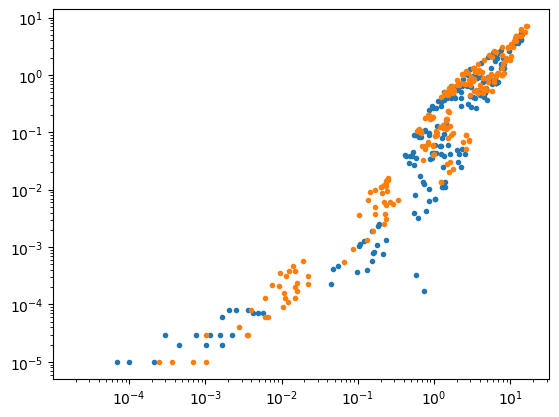

In [23]:
plt.plot(data_M16['I13CO(2-1)80'], data_M16['IC18O(2-1)80'], '.')
plt.plot(data_M16['I13CO(2-1)10'], data_M16['IC18O(2-1)10'], '.')

plt.loglog()

## Convert line luminosities in units of intensity [K] to flux [F_nu] following Appendix B in Bruderer (2013)
### In order to convert the intensity in units of Kelvin (K) into flux (F_nu), we require the knowledge of the telescope beam. Miotello et al. (2016) assumed a 10" Gaussian beam for their table

In [24]:
mom0_12CO = fits.open('/Users/kristina/Hamburgers/Draculas_Chivito/SMA/data/DraChi.briggs0.12CO.velcor.fixVel.lsrk.im.image_M0.fits')
print('12CO beam:', (mom0_12CO[0].header['BMAJ']*u.deg).to(u.arcsec), 'x', (mom0_12CO[0].header['BMIN']*u.deg).to(u.arcsec))

mom0_13CO = fits.open('/Users/kristina/Hamburgers/Draculas_Chivito/SMA/data/DraChi.briggs0.13CO.velcor.fixVel.lsrk.im.image_M0.fits')
print('13CO beam:', (mom0_13CO[0].header['BMAJ']*u.deg).to(u.arcsec), 'x', (mom0_13CO[0].header['BMIN']*u.deg).to(u.arcsec))

mom0_C18O = fits.open('/Users/kristina/Hamburgers/Draculas_Chivito/SMA/data/DraChi.briggs0.C18O.velcor.fixVel.lsrk.im.image_M0.fits')
print('C18O beam:', (mom0_C18O[0].header['BMAJ']*u.deg).to(u.arcsec), 'x', (mom0_C18O[0].header['BMIN']*u.deg).to(u.arcsec))

12CO beam: 3.8819830417633043 arcsec x 2.496291875839231 arcsec
13CO beam: 4.043223857879636 arcsec x 2.6484277248382533 arcsec
C18O beam: 4.083476543426513 arcsec x 2.6828415393829346 arcsec


In [25]:
beam_fwhm = 10*u.arcsec

#beam_SMA = 4.04*u.arcsec * 2.649*u.arcsec
beam_SMA = (mom0_13CO[0].header['BMAJ']*u.deg).to(u.arcsec) * (mom0_13CO[0].header['BMIN']*u.deg).to(u.arcsec) 

### Assuming a Gaussian beam with full width at halve maximum of θ_FWHM, the solid angle of the beam is:


In [26]:
delta_beam_solid_angle = np.pi*beam_fwhm**2./(4.*np.log(3.))
print(delta_beam_solid_angle, delta_beam_solid_angle.to(u.rad**2.))

delta_beam_solid_angle_SMA = np.pi*beam_SMA/(4.*np.log(3.))
print(delta_beam_solid_angle_SMA, delta_beam_solid_angle_SMA.to(u.rad**2.))

71.49002168450318 arcsec2 1.6803322489220065e-09 rad2
7.65528460989985 arcsec2 1.7993310537041607e-10 rad2


In [27]:
### rest frequencies from the 13CO (2-1) and C180 (2-1) lines
rest_freq_13CO = 220.39868*u.GHz
rest_freq_C18O = 219.56035*u.GHz

In [28]:
conv_factor_13CO = 2.73e-29*rest_freq_13CO**3.*beam_fwhm**2.
conv_factor_C18O = 2.73e-29*rest_freq_C18O**3.*beam_fwhm**2.

conv_factor_13CO_SMAbeam = 2.73e-29*rest_freq_13CO**3.*beam_SMA
conv_factor_C18O_SMAbeam = 2.73e-29*rest_freq_C18O**3.*beam_SMA

In [29]:
F_13CO_SMA = 14.0*u.Jy*u.km/u.s # 1.515659e1*u.Jy*u.km/u.s ## these fluxes were measured using the SMA beam
F_C18O_SMA = 8.6*u.Jy*u.km/u.s

Text(0.5, 1.0, '100 pc')

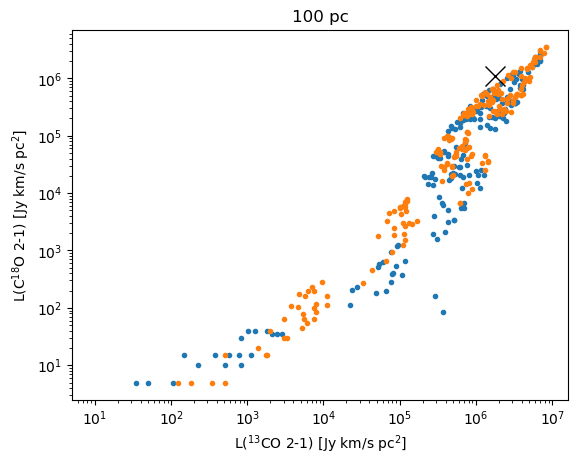

In [30]:
plt.plot((data_M16['I13CO(2-1)80']*u.K*u.km/u.s)* conv_factor_13CO * 3e22 * 4*np.pi * (100*u.pc)**2. / rest_freq_13CO,
         (data_M16['IC18O(2-1)80']*u.K*u.km/u.s)* conv_factor_C18O * 3e22 * 4*np.pi * (100*u.pc)**2. / rest_freq_C18O,
         '.')

plt.plot((data_M16['I13CO(2-1)10']*u.K*u.km/u.s)* conv_factor_13CO * 3e22 * 4*np.pi * (100*u.pc)**2. / rest_freq_13CO,
         (data_M16['IC18O(2-1)10']*u.K*u.km/u.s)* conv_factor_C18O * 3e22 * 4*np.pi * (100*u.pc)**2. / rest_freq_C18O,
         '.')


plt.plot(4*np.pi*(100*u.pc)**2.*F_13CO_SMA, 4*np.pi*(100*u.pc)**2.*F_C18O_SMA, 'x', c='black', markersize=15)

#plt.axvline(10**7)
#plt.axhline(4e6)

plt.xlabel('L($^{13}$CO 2-1) [Jy km/s pc$^2$]')
plt.ylabel('L(C$^{18}$O 2-1) [Jy km/s pc$^2$]')

plt.loglog()
plt.title('100 pc')

Text(0.5, 1.0, '370 pc')

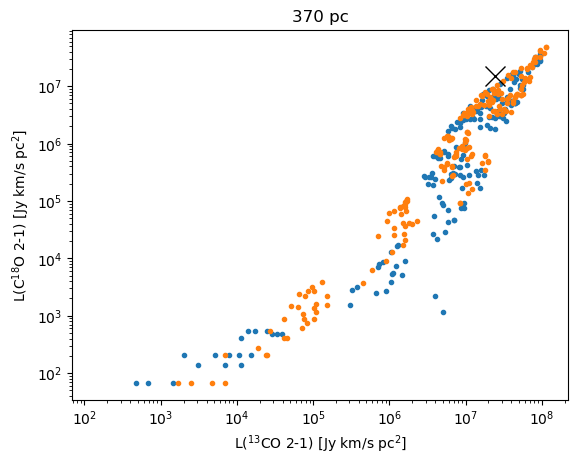

In [31]:
plt.plot((data_M16['I13CO(2-1)80']*u.K*u.km/u.s)* conv_factor_13CO * 3e22 * 4*np.pi * (370*u.pc)**2. / rest_freq_13CO,
         (data_M16['IC18O(2-1)80']*u.K*u.km/u.s)* conv_factor_C18O * 3e22 * 4*np.pi * (370*u.pc)**2. / rest_freq_C18O,
         '.')

plt.plot((data_M16['I13CO(2-1)10']*u.K*u.km/u.s)* conv_factor_13CO * 3e22 * 4*np.pi * (370*u.pc)**2. / rest_freq_13CO,
         (data_M16['IC18O(2-1)10']*u.K*u.km/u.s)* conv_factor_C18O * 3e22 * 4*np.pi * (370*u.pc)**2. / rest_freq_C18O,
         '.')

plt.plot(4*np.pi*(370*u.pc)**2.*F_13CO_SMA, 4*np.pi*(370*u.pc)**2.*F_C18O_SMA, 'x', c='black', markersize=15)

plt.xlabel('L($^{13}$CO 2-1) [Jy km/s pc$^2$]')
plt.ylabel('L(C$^{18}$O 2-1) [Jy km/s pc$^2$]')

plt.loglog()
plt.title('370 pc')

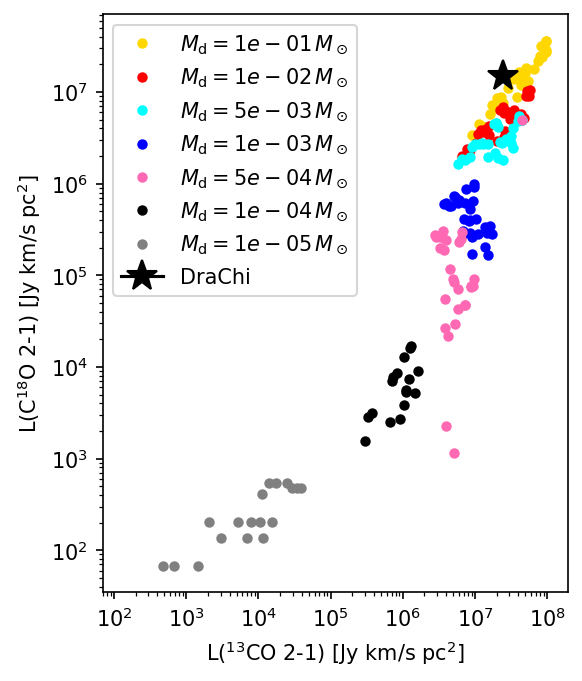

In [97]:
colors = ['gold', 'red', 'cyan', 'blue', 'hotpink', 'black', 'gray']

masses = [1e-1, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 1e-5]


plt.figure(figsize=(4,5), dpi=150)

for el in range(len(masses)):
    plt.plot((data_M16['I13CO(2-1)80'][data_M16['Mdisk']==masses[el]]*u.K*u.km/u.s)* conv_factor_13CO * 3e22 * 4*np.pi * (370*u.pc)**2. / rest_freq_13CO,
            (data_M16['IC18O(2-1)80'][data_M16['Mdisk']==masses[el]]*u.K*u.km/u.s)* conv_factor_C18O * 3e22 * 4*np.pi * (370*u.pc)**2. / rest_freq_C18O,
            '.', c=colors[el], label=r"$M_\mathrm{{d}}={:.0e}\,M_\odot$".format(masses[el]), markersize=10,  mew=0)

plt.plot(4*np.pi*(370*u.pc)**2.*F_13CO_SMA, 4*np.pi*(370.*u.pc)**2.*F_C18O_SMA, marker='*', c='black', markersize=15, label='DraChi')

plt.loglog()
#plt.xlim(6e1, 6e7)
#plt.ylim(1e0, 3e7)

plt.xlabel('L($^{13}$CO 2-1) [Jy km/s pc$^2$]')
plt.ylabel('L(C$^{18}$O 2-1) [Jy km/s pc$^2$]')

plt.legend()

#plt.savefig('/Users/kristina/Hamburgers/Draculas_Chivito/plots/13CO_C18O_lineluminosity.pdf', bbox_inches='tight')

## Stapper+2024
#### https://vizier.cds.unistra.fr/viz-bin/VizieR?-source=J/A+A/682/A149

In [52]:
data_S24 = ascii.read('../data/J:A+A:682:A149_Stapper24.csv', delimiter=';', data_start=3)

# select only high-inclination disks
data_S24 = data_S24[data_S24['inc'] == 70.]

data_S24

logMgas,Lstar,gamma,psi,hc,Rc,inc,L12COJ21,R12COJ21,L12COJ32,R12COJ32,L13COJ21,R13COJ21,L13COJ32,R13COJ32,LC18OJ21,RC18OJ21,LC18OJ32,RC18OJ32,LC17OJ21,RC17OJ21,LC17OJ32,RC17OJ32,L13C18OJ21,R13C18OJ21,L13C18OJ32,R13C18OJ32,L13C17OJ21,R13C17OJ21,L13C17OJ32,R13C17OJ32
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-5.0,5.0,0.4,0.1,0.05,5.0,70.0,47740.747820287856,21.33192539493832,118705.9288164896,21.350105630377683,9360.797180055906,20.885409364513013,28304.81575835491,20.935569958664416,1251.7408689001186,20.55044581061538,4501.67072838083,20.5469896193158,477.1249501007232,20.55380477034418,1828.154747834713,20.54884891212553,21.04966199148231,20.744448610645755,85.74387566800573,20.74125134435321,7.406116403047069,20.74967539598825,30.0457918706862,20.74632513086121
-5.0,5.0,0.4,0.1,0.05,10.0,70.0,92635.3500835777,27.652129481570903,234201.0920332357,27.738008072808025,14245.965726957344,22.52803575306296,46441.777682796266,22.659793184887185,968.1878346466692,21.007206440094468,3695.0604869009,21.003707453856897,353.8568277857899,21.00659657777088,1406.120530609847,20.9919595233449,21.303841081908946,21.7417061070417,87.18921532363413,21.71024468102869,7.512755084976208,21.755299492935706,30.6100335221827,21.722551309980805
-5.0,5.0,0.4,0.1,0.05,30.0,70.0,222704.6250815272,55.1986343664282,569463.2352173585,55.99721915998413,16756.818137581427,48.41970513880083,62281.50151146718,48.32325670835566,141.56784649189674,55.496255170026046,572.960081492911,54.97751511369498,50.751899254590775,55.53189131672913,204.4041805402815,54.997164490135695,8.790695219169473,45.177063021329225,35.65211527083854,44.71091663573807,3.136515379883821,45.15967982198973,12.6567283463945,44.67657370133436
-5.0,5.0,0.4,0.1,0.05,60.0,70.0,283828.72610430967,81.92858042057833,791132.0877087656,84.41110495309144,9865.986188828756,73.51348796707222,39609.235505955134,72.88533812116272,115.39403012167725,89.2675480249252,472.247276937485,88.27440604496324,41.44787778475176,89.38591329618986,168.7538851395291,88.37009499368959,2.236021276404198,89.33764362214856,9.202398402545311,88.39058794771815,0.7975668447175835,89.52262419060173,3.26374243940153,88.56892432155377
-5.0,5.0,0.4,0.1,0.05,200.0,70.0,34497.15464863944,181.2848902649152,143487.66408195498,169.91076957237553,572.0977790602637,195.737014208293,2368.3052984732603,184.9055277701681,23.64436517985617,218.8439296235449,97.5556049767998,210.7537504163841,8.548188752087434,218.62124317562487,35.06934137311268,210.1158809072115,0.4228107546221954,224.62281531278884,1.721085084387752,218.2936916986331,0.1495043760287866,223.91058496917617,0.603547334454776,217.73168366751932
-5.0,5.0,0.4,0.1,0.2,5.0,70.0,122478.21527417362,21.01909019783223,308478.2873532939,21.088429038461147,10654.152708179345,20.811786120220564,40785.97254152454,20.81449242413948,1163.6879935558552,20.596492479568983,4852.15874841368,20.58981111782913,407.3159973862173,20.59870076548038,1722.029754959929,20.592043352277816,14.258489054717648,20.663982230648266,61.51007007273103,20.65835658397787,4.918089201013111,20.66926422467071,21.139909407786,20.66359299085677
-5.0,5.0,0.4,0.1,0.2,10.0,70.0,215180.20963245,25.643894915629502,556125.1763928937,26.676639325404903,13178.727056320056,22.2703135141032,52792.50008942997,22.28891045871474,802.9745272492629,21.026100545335524,3431.33338659145,21.013747504992622,280.74392725430425,21.034131320724047,1207.233891897312,21.020052629547365,10.70741487537954,21.30840924861892,46.54293764873467,21.28840433566157,3.732045923264214,21.321400173760715,16.1660991200532,21.30071654420674
-5.0,5.0,0.4,0.1,0.2,30.0,70.0,301770.5488946171,40.679805303500245,902347.9958016564,42.325757548347006,8320.30280532303,39.42989276212069,35707.08499114046,39.24214166068944,59.11204890552396,46.26889067675456,2

Text(0.5, 1.0, '@100 pc')

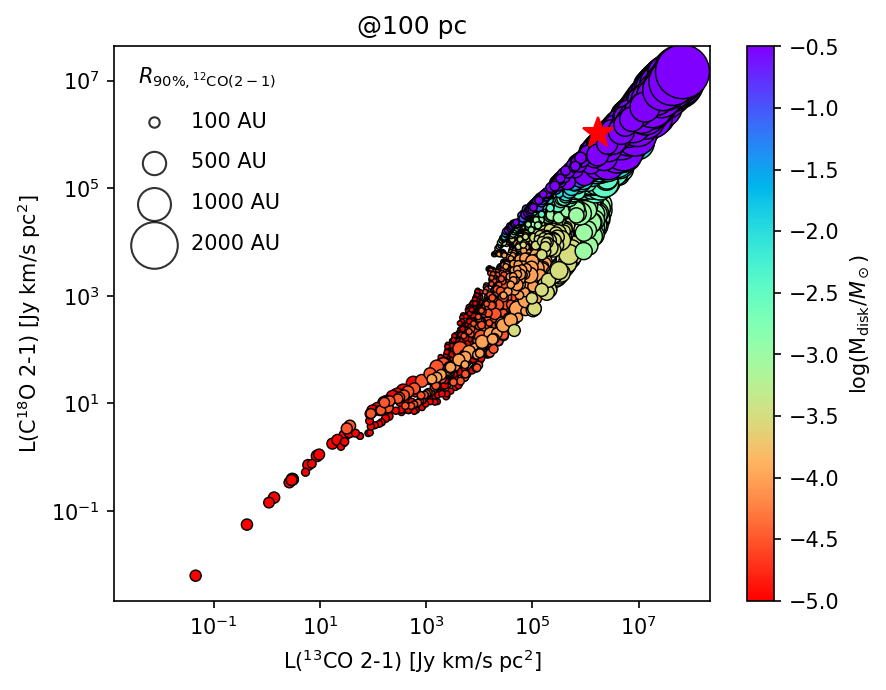

In [325]:
plt.figure(dpi=150)


x = data_S24['L13COJ21']#*(370./100.)**2.
y = data_S24['LC18OJ21']#*(370./100.)**2.
colors = data_S24['logMgas']

size_scale_factor = 0.5**2
sizes = data_S24['R12COJ21']*size_scale_factor

# Create scatter plot
scatter = plt.scatter(x, y, c=colors, s=sizes, alpha=1., cmap='rainbow_r', edgecolor='black', linewidth=0.7)

# Create legend for colors
cbar = plt.colorbar(scatter)
cbar.set_label('log(M$_\mathrm{disk}/M_\odot$)')

# Create legend for sizes
for size in [100,500,1000,2000]:
    plt.scatter([], [], s=size*size_scale_factor, c='white', edgecolor='black', alpha=0.8, label=str(size) + ' AU')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title=r'$R_{90\%,^{12}\mathrm{CO}(2-1)}$')

plt.plot(4*np.pi*(100.*u.pc)**2.*F_13CO_SMA, 4*np.pi*(100.*u.pc)**2.*F_C18O_SMA, marker='*', c='red', alpha=1., markersize=15, label='DraChi')

    
plt.xlabel('L($^{13}$CO 2-1) [Jy km/s pc$^2$]')
plt.ylabel('L(C$^{18}$O 2-1) [Jy km/s pc$^2$]')

plt.loglog()

#plt.xlim(1e5,1e8)
#plt.ylim(1e4, 1e8)

plt.title('@100 pc')



Text(0.5, 1.0, '@100 pc')

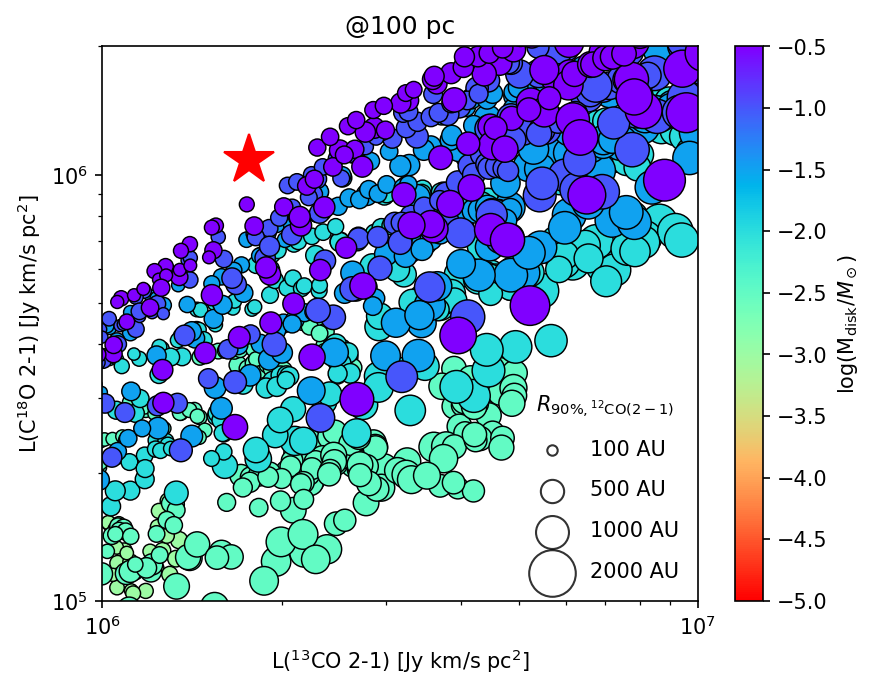

In [324]:
plt.figure(dpi=150)


x = data_S24['L13COJ21']#*(370./100.)**2.
y = data_S24['LC18OJ21']#*(370./100.)**2.
colors = data_S24['logMgas']

size_scale_factor = 0.5**2
sizes = data_S24['R12COJ21']*size_scale_factor

# Create scatter plot
scatter = plt.scatter(x, y, c=colors, s=sizes, alpha=1., cmap='rainbow_r', edgecolor='black', linewidth=0.7)

# Create legend for colors
cbar = plt.colorbar(scatter)
cbar.set_label('log(M$_\mathrm{disk}/M_\odot$)')

# Create legend for sizes
for size in [100,500,1000,2000]:
    plt.scatter([], [], s=size*size_scale_factor, c='white', edgecolor='black', alpha=0.8, label=str(size) + ' AU')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title=r'$R_{90\%,^{12}\mathrm{CO}(2-1)}$')

plt.plot(4*np.pi*(100.*u.pc)**2.*F_13CO_SMA, 4*np.pi*(100.*u.pc)**2.*F_C18O_SMA, marker='*', c='red', alpha=1., markersize=25, label='DraChi')

    
plt.xlabel('L($^{13}$CO 2-1) [Jy km/s pc$^2$]')
plt.ylabel('L(C$^{18}$O 2-1) [Jy km/s pc$^2$]')

plt.xlim(1e6, 1e7)
plt.ylim(1e5, 2e6)

plt.loglog()

plt.title('@100 pc')




Text(0.5, 1.0, '@370 pc')

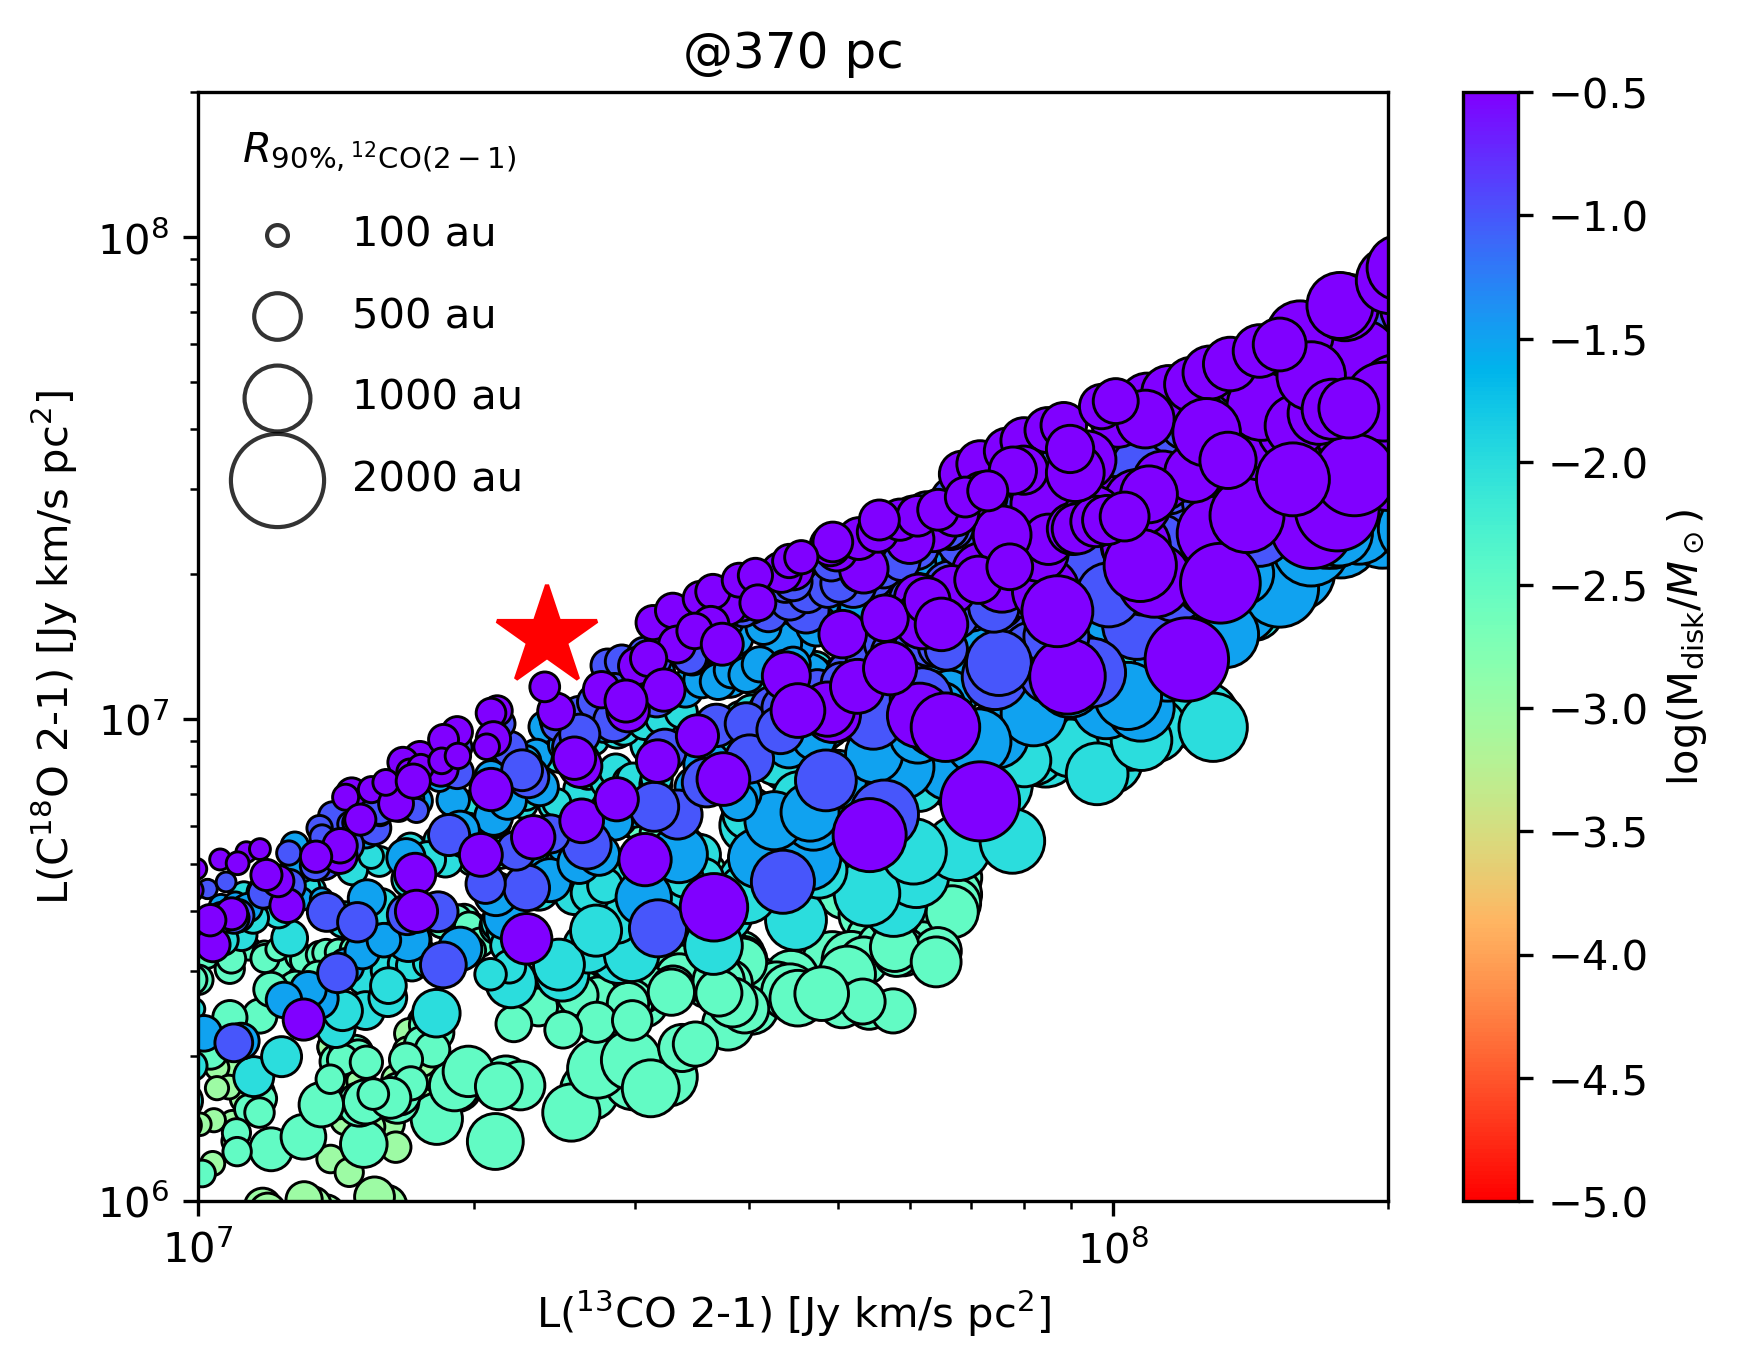

In [311]:
plt.figure(dpi=300)


x = data_S24['L13COJ21']*(370./100.)**2.
y = data_S24['LC18OJ21']*(370./100.)**2.
colors = data_S24['logMgas']

size_scale_factor = 0.5**2#*(370./100.)
sizes = data_S24['R12COJ21']*size_scale_factor

# Create scatter plot
scatter = plt.scatter(x, y, c=colors, s=sizes, alpha=1., cmap='rainbow_r', edgecolor='black', linewidth=0.7)

# Create legend for colors
cbar = plt.colorbar(scatter)
cbar.set_label('log(M$_\mathrm{disk}/M_\odot$)')

# Create legend for sizes
for size in [100,500,1000,2000]:
    plt.scatter([], [], s=size*size_scale_factor, c='white', edgecolor='black', alpha=0.8, label=str(size) + ' au')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title=r'$R_{90\%,^{12}\mathrm{CO}(2-1)}$')

plt.plot(4*np.pi*(370.*u.pc)**2.*F_13CO_SMA, 4*np.pi*(370.*u.pc)**2.*F_C18O_SMA, marker='*', c='red', alpha=1., markersize=25, label='DraChi')

    
plt.xlabel('L($^{13}$CO 2-1) [Jy km/s pc$^2$]')
plt.ylabel('L(C$^{18}$O 2-1) [Jy km/s pc$^2$]')

plt.xlim(1e7, 2e8)
plt.ylim(1e6, 2e8)

plt.loglog()

plt.title('@370 pc')




Text(0.5, 1.0, '@370 pc')

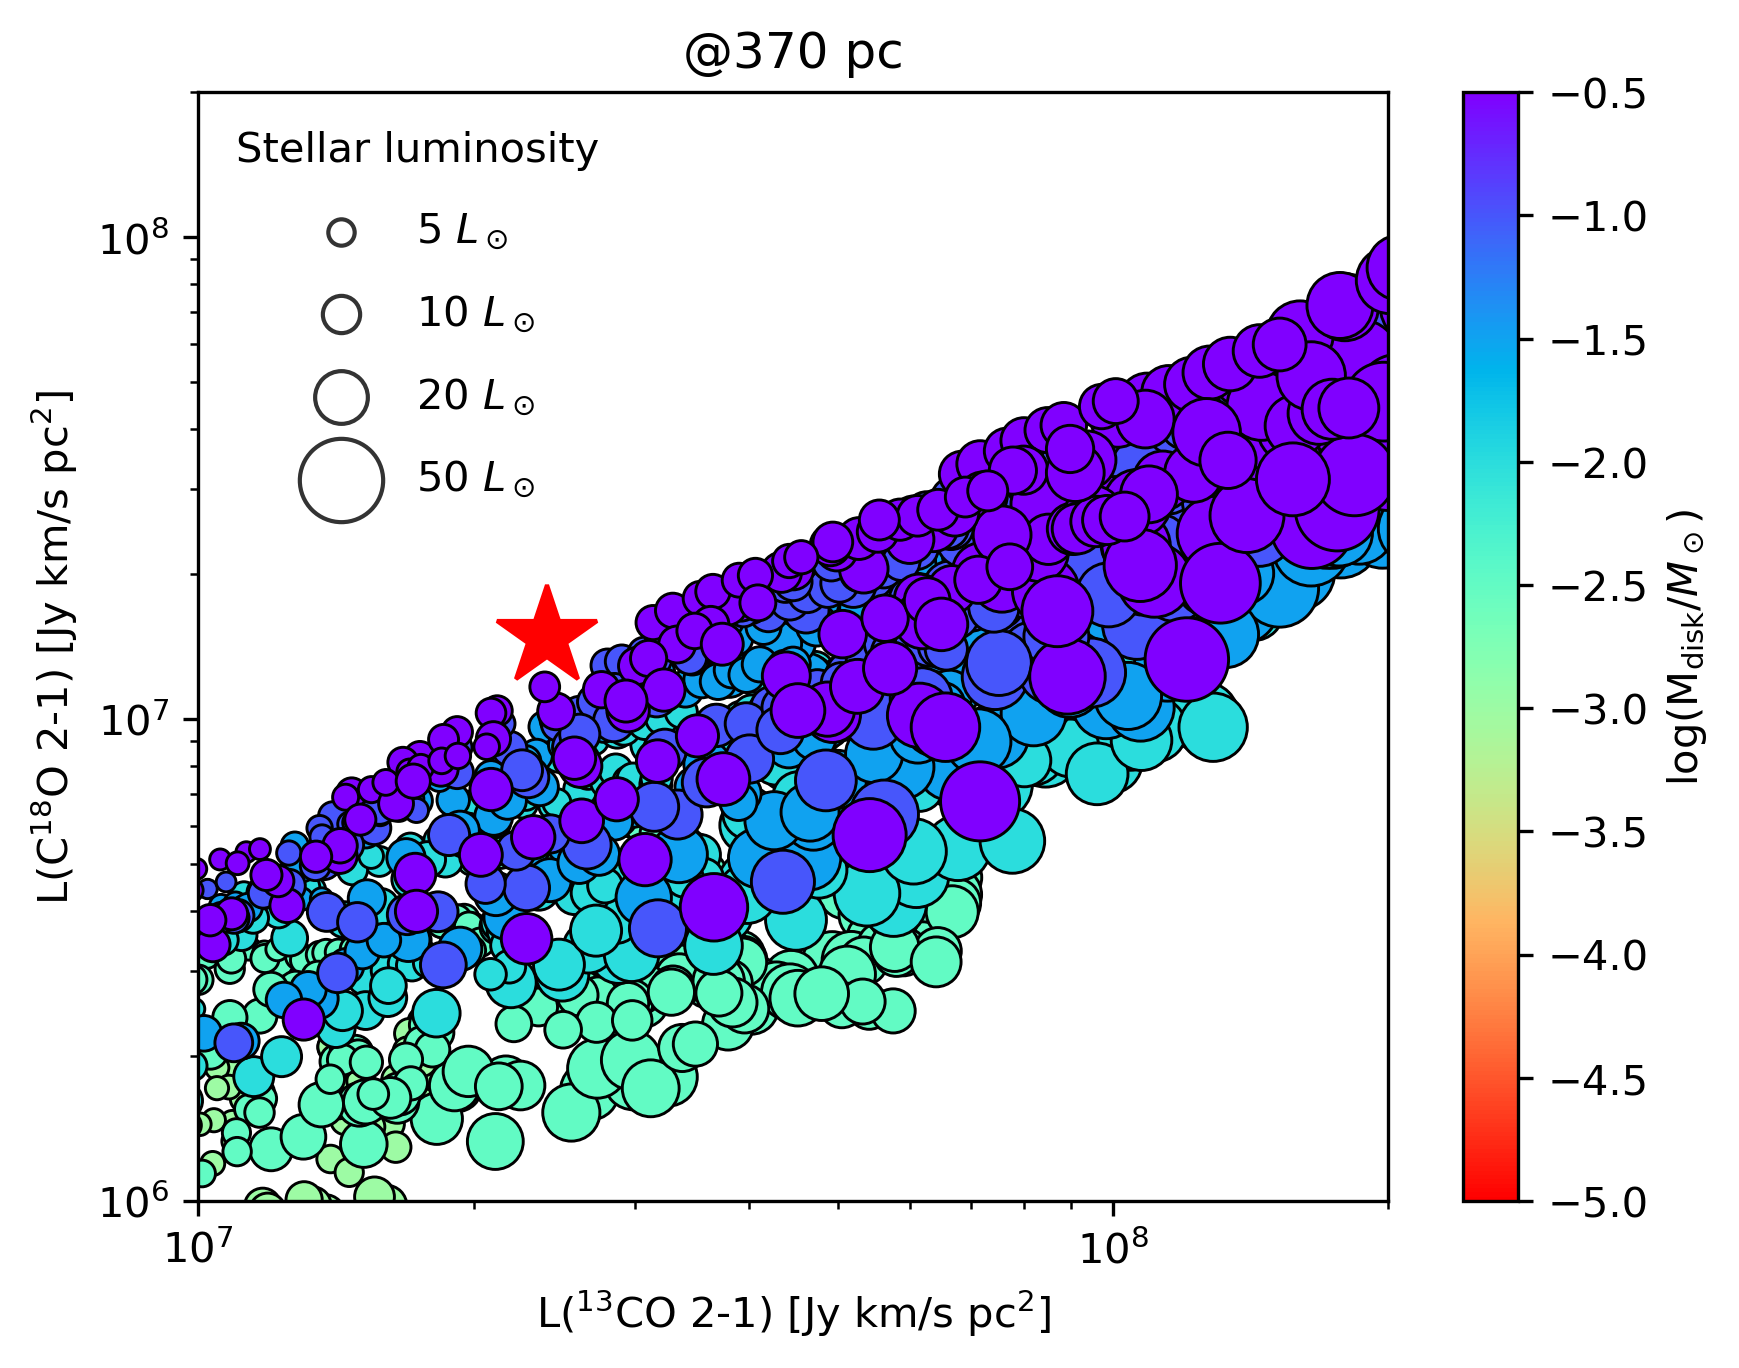

In [322]:
plt.figure(dpi=300)


x = data_S24['L13COJ21']*(370./100.)**2.
y = data_S24['LC18OJ21']*(370./100.)**2.
colors = data_S24['logMgas']

size_scale_factor = 2**3
lums = data_S24['Lstar']

# Create scatter plot
scatter = plt.scatter(x, y, c=colors, s=sizes, alpha=1., cmap='rainbow_r', edgecolor='black', linewidth=0.7)

# Create legend for colors
cbar = plt.colorbar(scatter)
cbar.set_label('log(M$_\mathrm{disk}/M_\odot$)')

# Create legend for sizes
for size in [5,10,20,50]:
    plt.scatter([], [], s=size*size_scale_factor, c='white', edgecolor='black', alpha=0.8, label=str(size) + ' $L_\odot$')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title=r'Stellar luminosity')

plt.plot(4*np.pi*(370.*u.pc)**2.*F_13CO_SMA, 4*np.pi*(370.*u.pc)**2.*F_C18O_SMA, marker='*', c='red', alpha=1., markersize=25, label='DraChi')

    
plt.xlabel('L($^{13}$CO 2-1) [Jy km/s pc$^2$]')
plt.ylabel('L(C$^{18}$O 2-1) [Jy km/s pc$^2$]')

plt.xlim(1e7, 2e8)
plt.ylim(1e6, 2e8)

plt.loglog()

plt.title('@370 pc')




In [319]:
np.unique(data_S24['Lstar'])

5.0
10.0
20.0
50.0
